# Unemployment Analysis with Python

### Executive Summary
This analysis quantifies the localized and macroeconomic impact of the 2020 Covid-19 national lockdown on India's labor force. By isolating pre-pandemic baselines (2019) and tracking the subsequent structural break, the data reveals:
* **The Macro Shock:** The national unemployment rate experienced a catastrophic surge, peaking immediately following the March 2020 lockdown implementation.
* **The Micro Disparity:** The urban informal sector was decimated disproportionately compared to rural areas, breaching 25% unemployment by April 2020 due to its lack of agricultural safety nets.
* **Policy Mandate:** The unequal recovery arc necessitates immediate, targeted interventions for urban centers, including urban employment guarantees and specialized upskilling initiatives for displaced service workers.

### Objective & Methodology
The objective of this project is to model the labor market elasticity and regional scarring caused by the pandemic. 

**Data Strategy:**
* **Dataset 1 (The Baseline & Micro-Lens):** Time-series data spanning May 2019 to June 2020, segmented by `Area` (Urban vs. Rural) to track demographic vulnerability.
* **Dataset 2 (The Macro-Lens):** Time-series data from Jan 2020 to Nov 2020 to map the national aggregate trajectory and recovery phase.

**Data Engineering Pipeline:**
The raw datasets were structurally compromised. Prior to analysis, a robust cleaning pipeline was executed to strip invisible trailing whitespaces from column headers, eradicate completely null trailing rows (phantom data), and force strictly formatted `datetime64` conversions to prevent chronological warping.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataframe is created and dataset is pushed inside the df

df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Drop the rows where all elements are missing

df1.dropna(how='all', inplace=True)

# Eradicate the whitespace from the column names

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Convert the 'Date' column to datetime format

df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

### 1. The Macro Trajectory: National Labor Collapse
Before segmenting the population, we must establish the national aggregate baseline. The visualization below models the mean national unemployment rate throughout 2020. The red zone marks the implementation of the strictest phases of the national lockdown (beginning March 24, 2020).

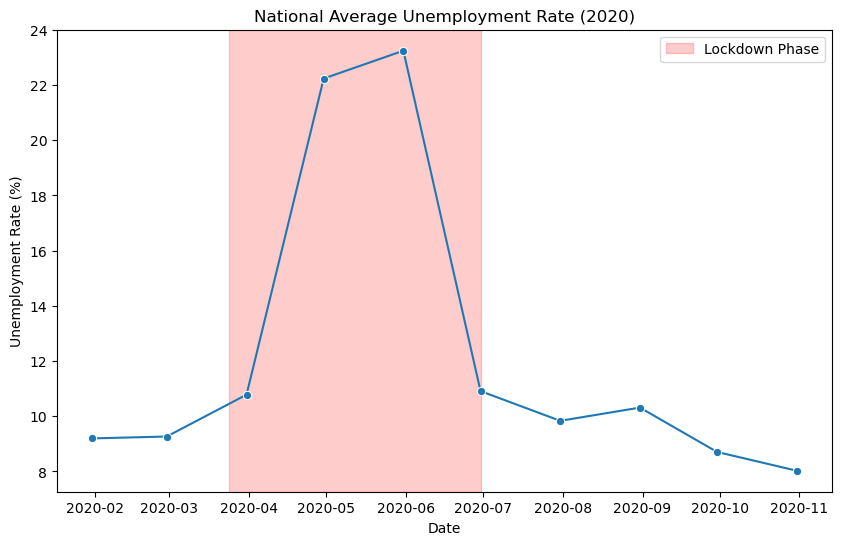

In [5]:
# grouping the data by 'date' in df2

avg_unemployment_rate = df2.groupby('Date')['Estimated Unemployment Rate (%)']\
    .mean().reset_index(name='avg_unemployment_rate')

# Visualization of the data using matplotlib and seaborn

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_unemployment_rate, x='Date', y='avg_unemployment_rate', marker='o')

# --- THE RED VERTICAL SPAN ---
start = pd.to_datetime('2020-03-24')
end = pd.to_datetime('2020-06-30')
plt.axvspan(start, end, color='red', alpha=0.2, label='Lockdown Phase')
# -----------------------------

plt.title('National Average Unemployment Rate (2020)')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

### 2. Micro Segmentation: Urban vs. Rural Vulnerability
A national average hides localized devastation. To understand who bore the brunt of the economic shock, we must isolate the data by region (Urban vs. Rural) spanning from the 2019 pre-Covid baseline through the initial recovery in June 2020.

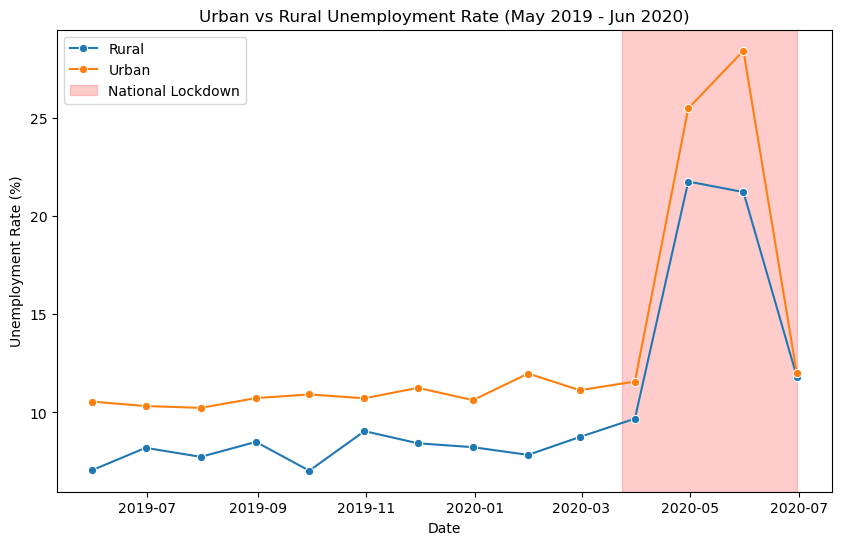

In [13]:
# grouping the data by 'date' in df1


avg_unemployment_by_date_area = df1.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)']\
    .mean().reset_index(name='avg')
    
# Visualization of the data in df1

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_unemployment_by_date_area, x='Date', y='avg', hue='Area', marker='o')

# --- THE RED VERTICAL SPAN ---
start = pd.to_datetime('2020-03-24')
end = pd.to_datetime('2020-06-30')
plt.axvspan(start, end, color='red', alpha=0.2, label='National Lockdown')
# -----------------------------

plt.title('Urban vs Rural Unemployment Rate (May 2019 - Jun 2020)')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

**Analytical Insight:**
Prior to the Covid-19 pandemic, India's urban unemployment rate consistently tracked higher than its rural counterpart. The implementation of the national lockdown in March 2020 caused a catastrophic structural break. While both sectors suffered, the urban sector experienced a significantly more violent spike, exposing the fragility of urban informal, retail, and service-based labor. As lockdown measures eased in June 2020, both markets exhibited high elasticity, sharply recovering toward their pre-pandemic baselines, though the urban sector retained deeper economic scarring.

### 3. Strategic Policy Interventions
Based on the data modeling above, the following resource allocations are recommended to mitigate future systemic shocks:

1. **Implement an Urban Employment Guarantee:** The data proves the urban informal sector is critically fragile. Policies akin to a national Urban NREGA are required to provide an immediate safety net for city-based daily wage earners during localized lockdowns.
2. **Targeted Skill Resiliency:** Because urban unemployment exhibited a steeper curve, municipal governments must fund immediate upskilling programs for displaced manufacturing and service workers, transitioning them into pandemic-resistant sectors (e.g., digital services, logistics).
3. **Agricultural Infrastructure Investment:** The rural data demonstrated a slight buffer due to agricultural continuity. Policy should reinforce this resilience by increasing subsidies for agricultural supply chains, ensuring the rural economy can sustain displaced migrant workforces returning from urban centers.